### Reference of the implmented method
- Article: "Plug-in martingales for testing exchangeability on-line"
- Authors: Valentina Fedorova, Alex Gammerman, Ilia Nouretdinov, Vladimir Vovk
- Year: 2012
- URL: https://arxiv.org/pdf/1204.3251

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

RANDOM_STATE = None

### Generate data
1. Generate exchangeable data
2. Generate non-exchangeable data

In [2]:
import numpy as np

def generate_exchangeable_data(n_samples=500):
    """
    Generate i.i.d. exchangeable labeled data.

    Data are sampled from two Gaussian classes with overlapping distributions.
    Order is randomized → exchangeable sequence.

    Returns
    -------
    dataset : list of tuples
        [(X_i, y_i), ...] where X_i is 2D, y_i in {0,1}
    """
    n0 = n_samples // 2
    n1 = n_samples - n0

    # make classes closer together to have meaningful alpha_i
    X0 = np.random.normal(loc=(-0.5, 0), scale=1.0, size=(n0, 2))
    X1 = np.random.normal(loc=(0.5, 0), scale=1.0, size=(n1, 2))

    y0 = np.zeros(n0, dtype=int)
    y1 = np.ones(n1, dtype=int)

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])

    dataset = list(zip(X, y))
    np.random.shuffle(dataset)  # crucial for exchangeability

    return dataset


def generate_time_series_data(n_samples=500):
    """
    Generate non-exchangeable time series data.

    Distribution drifts smoothly over time.
    This violates exchangeability but preserves local structure.

    Returns
    -------
    dataset : list of tuples
        [(X_i, y_i), ...] where X_i is 2D (time + value), y_i in {0,1}
    """
    X = []
    y = []

    for t in range(n_samples):
        # drifting mean (smooth sinusoidal)
        mean = np.sin(t / 50)

        x_val = np.random.normal(loc=mean, scale=0.5)

        # label based on deviation from current mean → dynamic structure
        label = int(x_val > mean)

        X.append([t, x_val])
        y.append(label)

    dataset = list(zip(np.array(X), np.array(y)))
    return dataset


def generate_step_change_data(n_samples=500):
    """
    Generate non-exchangeable data with abrupt change.

    First half of data from one Gaussian, second half from another.
    Useful for testing sudden non-exchangeability.

    Returns
    -------
    dataset : list of tuples
        [(X_i, y_i), ...]
    """
    n0 = n_samples // 2
    n1 = n_samples - n0

    # first half: mean -1
    X0 = np.random.normal(loc=-1, scale=0.5, size=(n0, 2))
    y0 = np.zeros(n0, dtype=int)

    # second half: mean +1
    X1 = np.random.normal(loc=1, scale=0.5, size=(n1, 2))
    y1 = np.ones(n1, dtype=int)

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])

    dataset = list(zip(X, y))
    return dataset

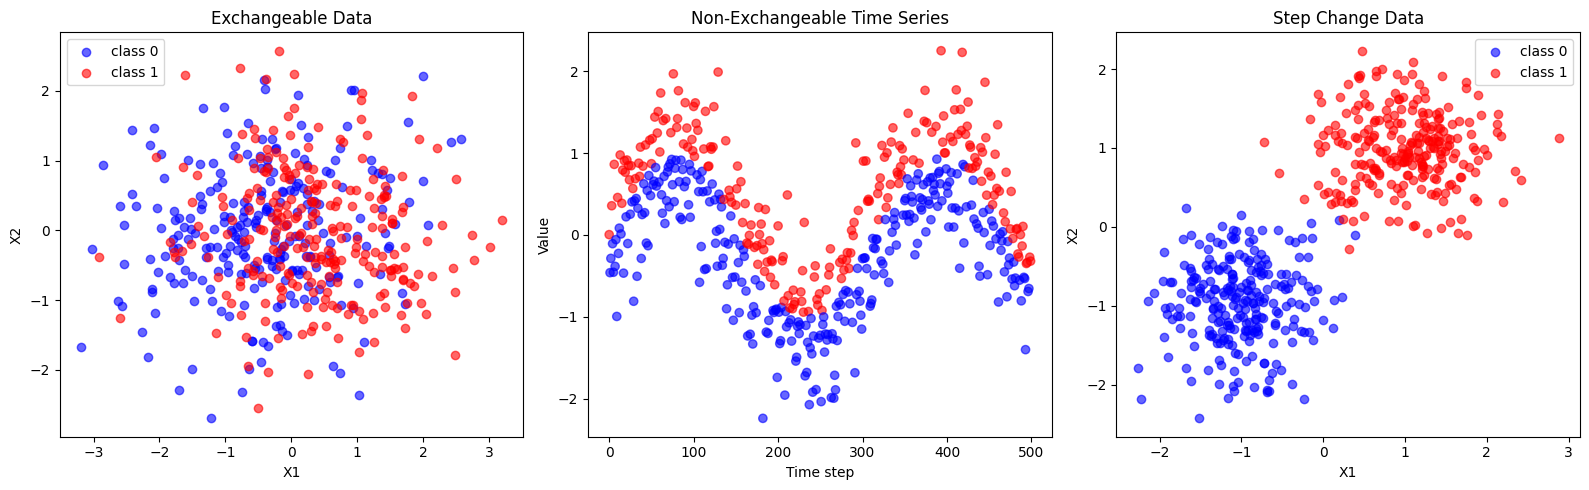

<Figure size 640x480 with 0 Axes>

In [3]:
exchangeable = generate_exchangeable_data()
timeseries = generate_time_series_data()
stepchange = generate_step_change_data()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Exchangeable data
X_ex = np.array([x for x, y in exchangeable])
y_ex = np.array([y for x, y in exchangeable])
axes[0].scatter(X_ex[y_ex==0][:,0], X_ex[y_ex==0][:,1], c='blue', label='class 0', alpha=0.6)
axes[0].scatter(X_ex[y_ex==1][:,0], X_ex[y_ex==1][:,1], c='red', label='class 1', alpha=0.6)
axes[0].set_title("Exchangeable Data")
axes[0].legend()
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")

# Time series (non-exchangeable)
X_ts = np.array([x for x, y in timeseries])
y_ts = np.array([y for x, y in timeseries])
axes[1].scatter(X_ts[:,0], X_ts[:,1], c=y_ts, cmap='bwr', alpha=0.6)
axes[1].set_title("Non-Exchangeable Time Series")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Value")

# Step change data (abrupt non-exchangeable)
X_sc = np.array([x for x, y in stepchange])
y_sc = np.array([y for x, y in stepchange])
axes[2].scatter(X_sc[y_sc==0][:,0], X_sc[y_sc==0][:,1], c='blue', label='class 0', alpha=0.6)
axes[2].scatter(X_sc[y_sc==1][:,0], X_sc[y_sc==1][:,1], c='red', label='class 1', alpha=0.6)
axes[2].set_title("Step Change Data")
axes[2].legend()
axes[2].set_xlabel("X1")
axes[2].set_ylabel("X2")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### Non-conformity score and p-values
1. Compute 1-NN ratio
2. Compute p-values

In [4]:
def compute_alpha(z_i, history):
    """
    Compute nonconformity score alpha_i.

    alpha_i = distance to nearest same-label neighbor
          divided by
          distance to nearest different-label neighbor

    Parameters
    ----------
    z_i : tuple (x_i, y_i)
    history : list of previous examples

    Returns
    -------
    float
    """

    x_i, y_i = z_i

    if len(history) == 0:
        return 1.0

    dist_same_label = []
    dist_diff_label = []

    for x_j, y_j in history:
        d = np.linalg.norm(x_i - x_j)
        if y_i == y_j:
            dist_same_label.append(d)
        else:
            dist_diff_label.append(d)

    min_same = min(dist_same_label) if dist_same_label else 1e-12
    min_diff = min(dist_diff_label) if dist_diff_label else 1e-12

    return min_same / (min_diff + 1e-12)


def compute_p_value(alpha_i, previous_alphas):
    """
    Compute p-value according to Algorithm 1 of the paper.

    p_i = ( #{alpha_j > alpha_i} + θ #{alpha_j = alpha_i} ) / n

    where theta ~ Uniform(0,1).

    Parameters
    ----------
    alpha_i : float
    previous_alphas : list

    Returns
    -------
    float
    """

    n = len(previous_alphas)

    if n == 0:
        return 0.5

    previous_alphas = np.asarray(previous_alphas)

    greater = np.sum(previous_alphas > alpha_i)
    equal = np.sum(previous_alphas == alpha_i)

    theta = np.random.rand()

    p_values = (greater + theta * equal) / n
    return np.clip(p_values, 1e-12, 1 - 1e-12)

### Martingales
1. Simple Mixture Martingale
2. Plug-in Martingale

NB : We need some batch data for initial estimation of the density function used in "Plug-in Martingale". Current implementition set it to 1 if len(historical p-value) < 20.

In [5]:
class SimpleMixtureMartingale:
    """
    Simple Mixture Martingale for testing exchangeability.

    This martingale is defined as the integral over \\varepsilon ∈ (0,1)
    of power martingales:

        M_n = \\int_0^1 M_n^(\\varepsilon) d\\varepsilon

    where each power martingale evolves as:

        M_n^(\\varepsilon) = \\prod_{i=1}^n \\varepsilon * p_i^(\\varepsilon - 1)

    Since the integral has no closed form, we approximate it
    numerically using a fixed grid of \\varepsilon values and trapezoidal
    integration.

    Parameters
    ----------
    epsilon_grid : array-like
        Grid of \\varepsilon values in (0,1). Endpoints 0 and 1 must be
        excluded to avoid numerical instability.

    Attributes
    ----------
    epsilon_grid : ndarray
        Discretization of \\varepsilon domain.

    power_martingale_by_eps : ndarray
        Current value of each power martingale M_n^{\\varepsilon}.

    current_martingale_value : float
        Value of the mixture martingale M_n.
    """

    def __init__(self, epsilon_grid=np.linspace(0.01, 0.99, 200)):
        self.epsilon_grid = epsilon_grid
        self.power_martingale_by_eps = np.ones_like(epsilon_grid, dtype=float)
        self.current_martingale_value = 1.0

    def update(self, p_value):
        """
        Update martingale with a new p-value.

        Parameters
        ----------
        p_value : float
            New p-value in (0,1].

        Returns
        -------
        float
            Updated martingale value.
        """

        # multiplicative update for each \\varepsilon
        self.power_martingale_by_eps *= (
            self.epsilon_grid * (p_value ** (self.epsilon_grid - 1))
        )

        # numerical integral over \\varepsilon
        self.current_martingale_value = np.trapezoid(
            self.power_martingale_by_eps,
            self.epsilon_grid
        )

        return float(self.current_martingale_value)


class PlugInMartingale:
    """
    Plug-in Martingale for testing exchangeability.

    Instead of using a fixed betting function, this martingale
    estimates the density of past p-values and bets proportionally
    to that estimated density.

    The density estimator follows the procedure described in
    the paper:

        1. Reflect p-values to reduce boundary bias
        2. Estimate density with KDE
        3. Set density = 0 outside [0,1]
        4. Renormalize so it integrates to 1 on [0,1]

    The martingale is updated as:

        M_n = M_{n-1} * \\widehat\\rho{p_n}

    where \\widehat\\rho is the estimated density.

    Attributes
    ----------
    p_history : list
        Past observed p-values.

    current_martingale_value : float
        Current value of martingale.
    """

    def __init__(self):
        self.p_history = []
        self.current_martingale_value = 1.0

    def _estimate_density(self, p):
        """
        Estimate density of p using reflected KDE and normalize
        over the unit interval.

        Parameters
        ----------
        p : float
            Evaluation point.

        Returns
        -------
        float
            Estimated density value.
        """

        # neutral start when insufficient data
        if len(self.p_history) < 20:
            return 1.0

        p_array = np.asarray(self.p_history)

        # reflection to reduce boundary bias
        reflected = np.concatenate([-p_array, p_array, 2 - p_array])

        kde = gaussian_kde(reflected, bw_method="silverman")

        # compute normalization constant over [0,1]
        grid = np.linspace(0, 1, 200)
        density_vals = kde(grid)
        normalization_val = np.trapezoid(density_vals, grid)

        # control against numerical failure
        if normalization_val <= 0 or not np.isfinite(normalization_val):
            return 1.0

        # density value at p
        density = kde([p])[0] / normalization_val

        # enforce support restriction
        if p < 0 or p > 1:
            density = 0.0

        return max(float(density), 1e-12)

    def update(self, p_value):
        """
        Update martingale with new p-value.

        Parameters
        ----------
        p_value : float
            New p-value.

        Returns
        -------
        float
            Updated martingale value.
        """

        rho_hat = self._estimate_density(p_value)
        self.current_martingale_value *= rho_hat
        self.p_history.append(p_value)

        return float(self.current_martingale_value)

### Run experiment
1. Run experiment method
2. Run experiment for exchangeable data
3. Run experiment for non-exchangeable data

In [6]:
def run_exchangeability_test(stream, martingale_objects, shuffle=False):
    """
    Run online exchangeability test.

    Pipeline per observation z_i:
        1. compute alpha_i
        2. compute p_i
        3. update martingales
        4. append z_i to history

    Parameters
    ----------
    stream : iterable of z_i
    martingale_objects : dict(name -> martingale instance)
    shuffle : bool

    Returns
    -------
    dict of lists
        log martingale values
    """

    stream = list(stream)

    if shuffle:
        np.random.shuffle(stream)

    history = []
    alpha_history = []

    results = {name: [] for name in martingale_objects}

    for z_i in stream:

        # Step 1: compute the conformity score alpha_i
        alpha_i = compute_alpha(z_i, history)

        # Step 2: compute p-value p_i
        p_i = compute_p_value(alpha_i, alpha_history)

        # Step 3: update martingales
        for name, mart in martingale_objects.items():
            results[name].append(np.log10(mart.update(p_i)))

        # Step 4: update histories
        history.append(z_i)
        alpha_history.append(alpha_i)

    return results

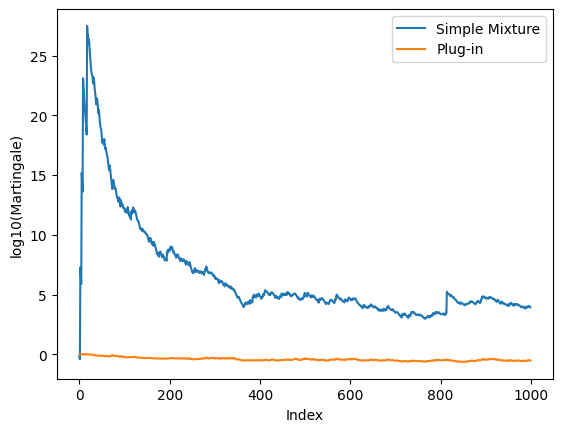

In [7]:
# Martingales
martingales_dict = {
    "simple": SimpleMixtureMartingale(),
    "plugin": PlugInMartingale()
}
# Exhangeable data
data = generate_exchangeable_data(n_samples=1000)
res = run_exchangeability_test(stream=data, martingale_objects=martingales_dict, shuffle=False)

plt.plot(res['simple'], label='Simple Mixture')
plt.plot(res['plugin'], label='Plug-in')
plt.xlabel('Index')
plt.ylabel('log10(Martingale)')
plt.legend()
plt.show()

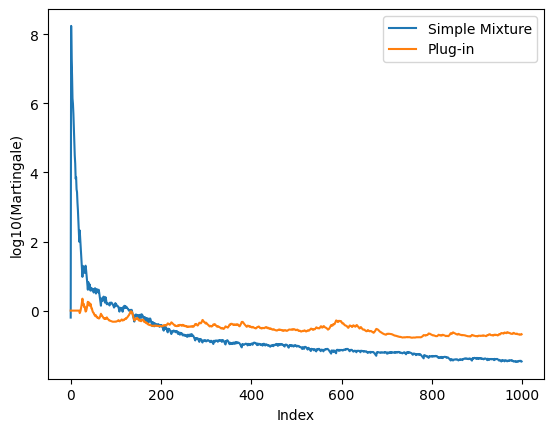

In [8]:
# Martingales
martingales_dict = {
    "simple": SimpleMixtureMartingale(),
    "plugin": PlugInMartingale()
}
# Non-exchangeable data
data2 = generate_time_series_data(n_samples=1000)
res2 = run_exchangeability_test(stream=data2, martingale_objects=martingales_dict, shuffle=False)

plt.plot(res2['simple'], label='Simple Mixture')
plt.plot(res2['plugin'], label='Plug-in')
plt.xlabel('Index')
plt.ylabel('log10(Martingale)')
plt.legend()
plt.show()

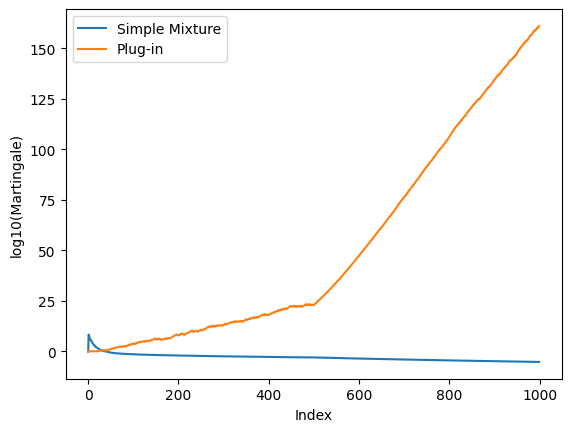

In [9]:
# Martingales
martingales_dict = {
    "simple": SimpleMixtureMartingale(),
    "plugin": PlugInMartingale()
}
# Non-exchangeable data
data3 = generate_step_change_data(n_samples=1000)
res3 = run_exchangeability_test(stream=data3, martingale_objects=martingales_dict, shuffle=False)

plt.plot(res3['simple'], label='Simple Mixture')
plt.plot(res3['plugin'], label='Plug-in')
plt.xlabel('Index')
plt.ylabel('log10(Martingale)')
plt.legend()
plt.show()

### Possible Testing API

In [10]:
import numpy as np
from typing import List, Optional, Tuple

class TestMartingale:
    """
    Generic API for online martingale testing of exchangeability.

    This class provides a structured interface to:
        1. Load data (classification or regression)
        2. Compute non-conformity scores
        3. Generate online p-values
        4. Update martingale(s)
        5. Run the online test over a dataset
        6. Summarize and visualize results

    The class is designed to be extensible for different martingale
    strategies (Simple Mixture, Plug-in, or user-defined).

    Attributes
    ----------
    martingale_type : str
        Name of the martingale strategy ("simple", "plugin", etc.)
    p_values : list of float
        Sequence of online p-values
    scores : list of float
        Sequence of non-conformity scores
    results : dict
        Stores martingale trajectories and summary statistics
    """

    def __init__(self, martingale_type: str = "plugin"):
        self.martingale_type = martingale_type
        self.p_values: List[float] = []
        self.scores: List[float] = []
        self.results: dict = {}

        # Placeholder for martingale instance (to be initialized)
        self.martingale = None

    # Step 1: Load / prepare data
    def load_data(self, X: np.ndarray, y: np.ndarray):
        """
        Load dataset into the test object.

        Parameters
        ----------
        X : np.ndarray
            Features (n_samples, n_features)
        y : np.ndarray
            Labels or target values

        Notes
        -----
        The data can be shuffled or kept in order depending on
        the test scenario (exchangeable or non-exchangeable).
        """
        raise NotImplementedError

    # Step 2: Compute non-conformity score
    def compute_nonconformity_score(self, x: np.ndarray, y: int, history: List[Tuple[np.ndarray,int]]) -> float:
        """
        Compute the non-conformity score alpha_i for a single example.

        Parameters
        ----------
        x : np.ndarray
            Feature vector for the current sample
        y : int or float
            Label / target for the current sample
        history : list of tuples
            Past examples [(x_j, y_j), ...]

        Returns
        -------
        float
            Non-conformity score for the current example

        Notes
        -----
        This function can be based on 1-NN ratio, regression residuals,
        or any user-defined scoring function.
        """
        raise NotImplementedError

    # Step 3: Generate online p-value
    def generate_p_value(self, alpha_i: float) -> float:
        """
        Generate the online p-value for the current non-conformity score.

        Parameters
        ----------
        alpha_i : float
            Current non-conformity score

        Returns
        -------
        float
            Online p-value in [0,1]

        Notes
        -----
        Can follow Algorithm 1 from Vovk et al. (2012):
        p_i = (number of previous scores > alpha_i + random tie adjustment) / n
        """
        raise NotImplementedError

    # Step 4: Initialize martingale
    def initialize_martingale(self):
        """
        Initialize the chosen martingale strategy.

        Notes
        -----
        Should instantiate self.martingale depending on self.martingale_type,
        e.g., SimpleMixtureMartingale or PlugInMartingale.
        """
        raise NotImplementedError

    # Step 5: Update martingale
    def update_martingale(self, p_value: float) -> float:
        """
        Update the martingale with the new p-value.

        Parameters
        ----------
        p_value : float
            New online p-value

        Returns
        -------
        float
            Updated martingale value
        """
        raise NotImplementedError

    # Step 6: Run the online test
    def run(self, dataset: List[Tuple[np.ndarray,int]]):
        """
        Run the online martingale test over a full dataset.

        Parameters
        ----------
        dataset : list of tuples
            [(x_i, y_i), ...] in sequential order

        Notes
        -----
        - Computes scores, p-values, and updates martingale at each step
        - Stores trajectories in self.results
        """
        raise NotImplementedError

    # Step 7: Summarize / visualize results
    def summarize(self):
        """
        Generate a summary of the online martingale test.

        Returns
        -------
        dict
            Contains martingale trajectory, p-values, scores, and optional plots

        Notes
        -----
        - Can include log-martingale plots over time
        - Histograms of p-values
        - Statistical summaries (max, final value)
        """
        raise NotImplementedError